# 05 — LightGBM

Primary model. Gradient boosting on tabular data consistently outperforms
Random Forest in accuracy and is significantly faster to train, which makes
a proper hyperparameter search feasible.

Additionally, LightGBM has native SHAP support, which lets us explain
individual predictions — important for a project like this where knowing
*why* a station is predicted to be full is as valuable as the number.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform

from src.utils.config import PATHS, FEATURES, TARGET, SPLIT_DATE, RANDOM_STATE, DATASET_FILE
from src.models.evaluate import (
    regression_metrics, plot_predictions, plot_residuals,
    plot_feature_importance, plot_error_by_group
)

print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Load and split

In [2]:
df = pd.read_parquet(DATASET_FILE)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

train = df[df['datetime_hour'] < SPLIT_DATE]
test  = df[df['datetime_hour'] >= SPLIT_DATE]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

avg_capacity = float(df['capacity'].drop_duplicates().mean())
print(f'Train: {len(train):,}  Test: {len(test):,}')

Train: 16,476,930  Test: 3,665,100


---
## 2. Sample for hyperparameter search

In [3]:
SEARCH_SAMPLE = 500_000

# Searching over the full ~16M train rows would take many hours.
# A 500k stratified sample preserves the distribution across horizons
# and gives the search enough signal to find good hyperparameters quickly.
train_sample = (
    train
    .groupby('horizon_hours', group_keys=False)
    .apply(lambda g: g.sample(
        n=min(len(g), SEARCH_SAMPLE // train['horizon_hours'].nunique()),
        random_state=RANDOM_STATE
    ))
)
train_sample = train_sample.sort_values('datetime_hour').reset_index(drop=True)

X_search = train_sample[FEATURES]
y_search = train_sample[TARGET]
print(f'Search sample: {len(train_sample):,} rows ({len(train_sample)/len(train)*100:.1f}% of train)')

C:\Users\user\AppData\Local\Temp\ipykernel_15388\1527483690.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(


Search sample: 500,000 rows (3.0% of train)


---
## 3. Hyperparameter search

In [4]:
tscv = TimeSeriesSplit(n_splits=3, gap=168)

param_dist = {
    # Number of boosting rounds. LightGBM adds one tree per round to correct
    # the residuals of the previous ensemble. More rounds = finer corrections,
    # but too many will overfit — that's what learning_rate and regularization control.
    'n_estimators':      [200, 300, 500, 700],

    # Max number of leaves per tree. LightGBM grows leaf-wise (best-first) rather
    # than depth-wise, so num_leaves is the primary complexity knob. More leaves
    # = more complex patterns captured, but also more risk of overfitting.
    'num_leaves':        [31, 63, 95, 127],

    # -1 means no depth limit — num_leaves controls complexity instead.
    # Setting a cap adds an extra safety net against very deep paths.
    'max_depth':         [-1, 8, 12, 16],

    # Shrinks each tree's contribution. Lower rate = the model learns more slowly
    # but generalises better, provided n_estimators is high enough to compensate.
    'learning_rate':     [0.03, 0.05, 0.08, 0.12],

    # Row subsampling per tree (bagging). Using only a fraction of rows per round
    # introduces randomness that reduces overfitting, similar to Random Forest.
    'subsample':         [0.7, 0.8, 0.9, 1.0],

    # Feature subsampling per tree. Same idea as subsample but applied to columns.
    # Particularly useful when some features are strongly correlated.
    'colsample_bytree':  [0.6, 0.7, 0.8, 1.0],

    # Min number of samples in a leaf. One of the most effective regularization
    # params in LightGBM — prevents the model from memorising tiny subgroups.
    'min_child_samples': [20, 40, 60, 100],

    # L1 regularization on leaf weights — pushes small weights to zero (sparse model).
    'reg_alpha':         [0.0, 0.01, 0.05, 0.1],

    # L2 regularization on leaf weights — penalises large weights (smoother model).
    'reg_lambda':        [0.0, 0.01, 0.05, 0.1],
}

lgbm = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

search = RandomizedSearchCV(
    lgbm,
    param_distributions=param_dist,
    # 15 iterations on the 500k sample — fast enough to run in a few minutes.
    n_iter=15,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    verbose=2,
    # n_jobs=1 here because LightGBM already parallelises internally via n_jobs=-1.
    # Running outer and inner parallelism simultaneously often hurts performance.
    n_jobs=1,
)

search.fit(X_search, y_search)
print(f'Best CV RMSE: {-search.best_score_:.4f}')
print(f'Best params:  {search.best_params_}')

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END colsample_bytree=0.7, learning_rate=0.12, max_depth=8, min_child_samples=100, n_estimators=200, num_leaves=63, reg_alpha=0.05, reg_lambda=0.01, subsample=0.9; total time=   3.5s
[CV] END colsample_bytree=0.7, learning_rate=0.12, max_depth=8, min_child_samples=100, n_estimators=200, num_leaves=63, reg_alpha=0.05, reg_lambda=0.01, subsample=0.9; total time=   4.1s
[CV] END colsample_bytree=0.7, learning_rate=0.12, max_depth=8, min_child_samples=100, n_estimators=200, num_leaves=63, reg_alpha=0.05, reg_lambda=0.01, subsample=0.9; total time=   5.0s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=16, min_child_samples=100, n_estimators=300, num_leaves=95, reg_alpha=0.1, reg_lambda=0.0, subsample=1.0; total time=   4.9s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=16, min_child_samples=100, n_estimators=300, num_leaves=95, reg_alpha=0.1, reg_lambda=0.0, subsample=1.0; total time=   6.4s
[CV] E

---
## 4. Retrain on full train set with best hyperparameters

In [5]:
# The search found the best config on the 500k sample. Now we train
# the final model on all training data to get the most accurate weights.
best_lgbm = lgb.LGBMRegressor(
    **search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
best_lgbm.fit(X_train, y_train)
print('Retrained on full train set.')

Retrained on full train set.


---
## 5. Evaluate best model

In [6]:
y_pred_train = best_lgbm.predict(X_train)
y_pred_test  = best_lgbm.predict(X_test)

print('=== LIGHTGBM ===')
m_train = regression_metrics(y_train, y_pred_train, 'Train', avg_capacity)
print()
m_test  = regression_metrics(y_test,  y_pred_test,  'Test',  avg_capacity)

=== LIGHTGBM ===
  Train
    RMSE : 0.1666
    MAE  : 0.1245
    R²   : 0.6349
    RMSE in bikes : ±5.4

  Test
    RMSE : 0.1632
    MAE  : 0.1235
    R²   : 0.6571
    RMSE in bikes : ±5.3


---
## 6. RMSE by horizon

 horizon_hours     rmse
             1 0.093191
             3 0.149835
             6 0.169375
            12 0.194241
            24 0.189267


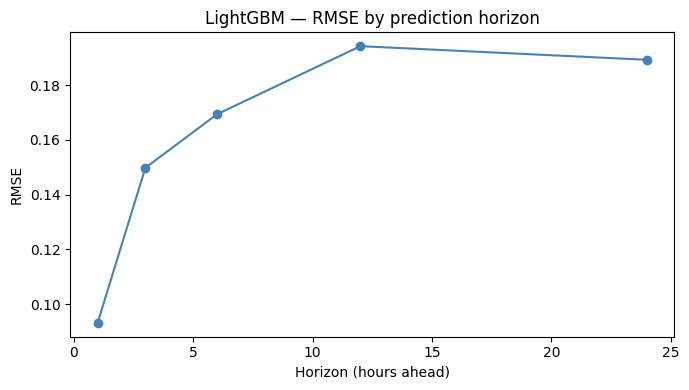

In [7]:
from sklearn.metrics import mean_squared_error

rows = []
for h in sorted(test['horizon_hours'].unique()):
    mask = test['horizon_hours'] == h
    rmse = float(np.sqrt(mean_squared_error(y_test[mask], y_pred_test[mask])))
    rows.append({'horizon_hours': h, 'rmse': rmse})

df_h = pd.DataFrame(rows)
print(df_h.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_h['horizon_hours'], df_h['rmse'], marker='o', color='steelblue')
ax.set_xlabel('Horizon (hours ahead)')
ax.set_ylabel('RMSE')
ax.set_title('LightGBM — RMSE by prediction horizon')
plt.tight_layout()
plt.savefig(PATHS['figures'] / '05_lgbm_rmse_by_horizon.png', dpi=150)
plt.show()

---
## 7. Error analysis by distance to beach

Stations near the beach have very different usage patterns from central ones.

C:\Users\user\AppData\Local\Temp\ipykernel_15388\2972951217.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_eval.groupby('dist_group')['sq_err']


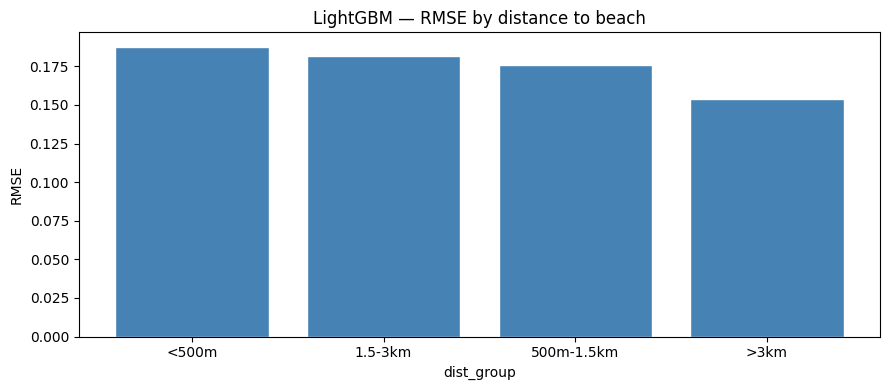

In [8]:
test_eval = test.copy()
test_eval['y_pred'] = y_pred_test
test_eval['sq_err'] = (test_eval[TARGET] - test_eval['y_pred']) ** 2

test_eval['dist_group'] = pd.cut(
    test_eval['dist_beach'],
    bins=[0, 0.5, 1.5, 3, 100],
    labels=['<500m', '500m-1.5km', '1.5-3km', '>3km']
)

rmse_by_dist = (
    test_eval.groupby('dist_group')['sq_err']
    .mean().apply(np.sqrt)
    .reset_index()
    .rename(columns={'sq_err': 'rmse', 'dist_group': 'group'})
)

fig = plot_error_by_group(rmse_by_dist.rename(columns={'group': 'dist_group'}),
                          group_col='dist_group',
                          title='LightGBM — RMSE by distance to beach')
fig.savefig(PATHS['figures'] / '05_lgbm_rmse_by_dist.png', dpi=150)
plt.show()

---
## 8. SHAP — global feature importance

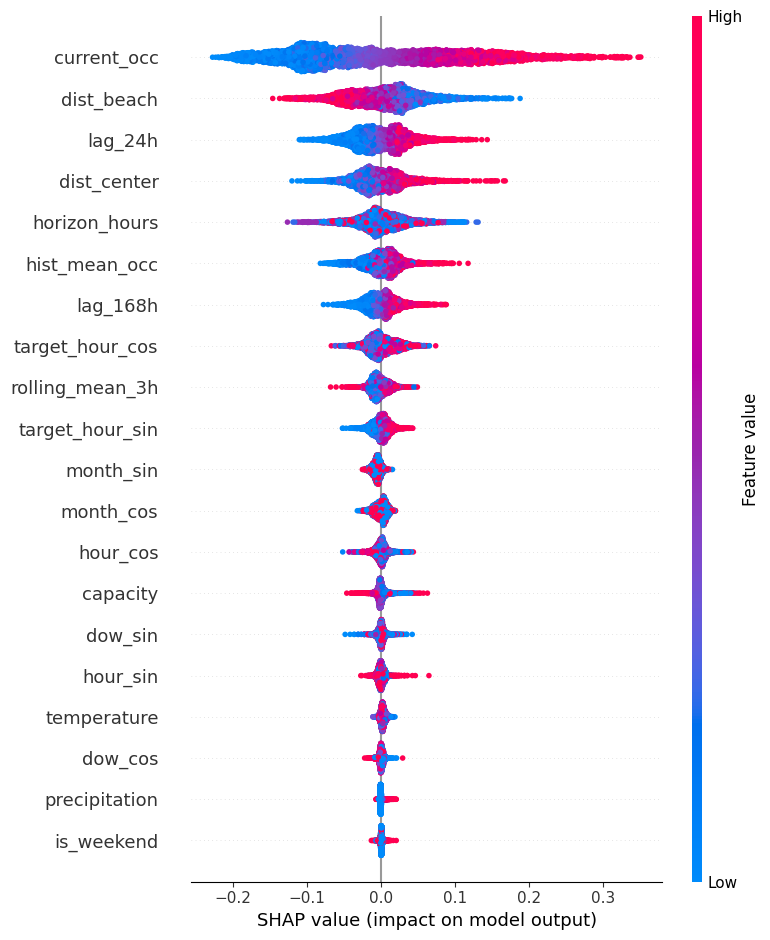

In [9]:
# Use a sample to keep computation time reasonable
sample_idx = X_test.sample(5000, random_state=RANDOM_STATE).index
X_sample   = X_test.loc[sample_idx]

explainer   = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig(PATHS['figures'] / '05_lgbm_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. SHAP — single prediction example

This is the kind of explanation you'd expose in a real app: why did the model predict this occupancy for this station at this time?

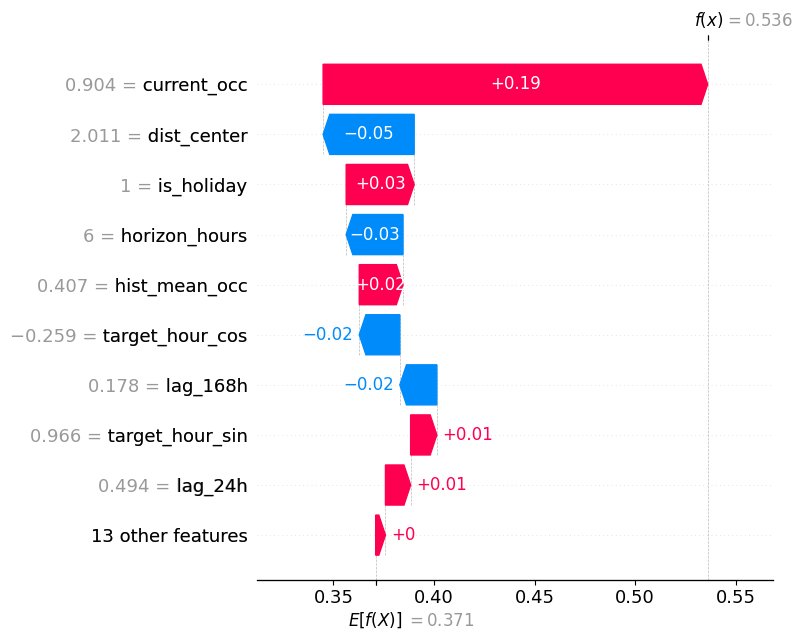

In [10]:
# Pick one row and explain it
row_idx = 0
shap.waterfall_plot(
    shap.Explanation(values=shap_values[row_idx],
                     base_values=explainer.expected_value,
                     data=X_sample.iloc[row_idx],
                     feature_names=FEATURES),
    show=False
)
plt.tight_layout()
plt.savefig(PATHS['figures'] / '05_lgbm_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Prediction plots

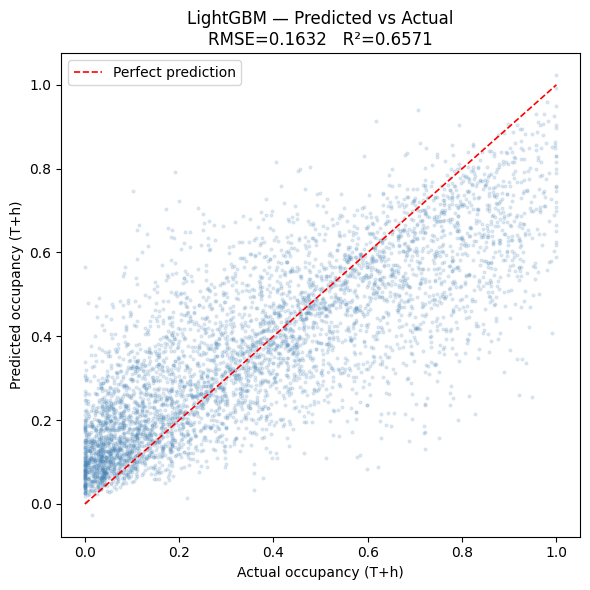

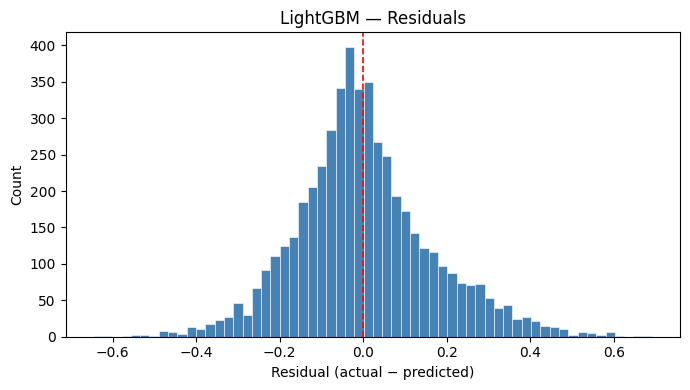

In [11]:
fig = plot_predictions(y_test.values, y_pred_test,
                       rmse=m_test['rmse'], r2=m_test['r2'],
                       title='LightGBM — Predicted vs Actual')
fig.savefig(PATHS['figures'] / '05_lgbm_predictions.png', dpi=150)
plt.show()

fig = plot_residuals(y_test.values, y_pred_test, title='LightGBM — Residuals')
fig.savefig(PATHS['figures'] / '05_lgbm_residuals.png', dpi=150)
plt.show()

---
## 11. Save model

In [12]:
model_path = PATHS['models'] / 'lightgbm.joblib'
joblib.dump(best_lgbm, model_path)
print(f'Model saved to {model_path}')

Model saved to C:\Users\user\Downloads\Data Science ML Bicing bcn\Data Science ML Bicing\bicing-occupancy-prediction\models\lightgbm.joblib
